# Visualización de Datos
## Mini portafolio: 5 visualizaciones con datos reales de Airbnb NYC

---
## Setup

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Estilo SWD 
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.grid':         False,
    'grid.color':        '#E8E8E8',
    'grid.linewidth':    0.7,
    'font.family':       'sans-serif',
    'axes.titlepad':     12,
})

ACENTO = '#1f77b4'   # azul 
SECUNDARIO   = '#e49444'   # naranja
GRIS   = '#9B9B9B'   # gris
ALERTA = '#d62728'   # rojo 


In [85]:
# Dataset: Airbnb NYC de la página Inside Airbnb (fuente pública)
URL = 'https://data.insideairbnb.com/united-states/ny/new-york-city/2024-09-04/visualisations/listings.csv'

# Utilizamos el dataset airbnb_nyc_2024 
df = pd.read_csv("airbnb_nyc_2024.csv")

# Limpieza básica
df_clean = df[(df['price'] > 10) & (df['price'] < 1500)].copy()

print(f'Dataset cargado: {len(df):,} listings originales')
print(f'Tras filtro de precio (>$10 y <$1,500): {len(df_clean):,} listings')
print(f'Barrios: {sorted(df["neighbourhood_group"].dropna().unique())}')
print(f'Tipos de alojamiento: {df["room_type"].unique()}')

Dataset cargado: 36,138 listings originales
Tras filtro de precio (>$10 y <$1,500): 36,138 listings
Barrios: ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']
Tipos de alojamiento: ['Private room' 'Entire home/apt' 'Hotel room' 'Shared room']



## Visualización 1 · Distribución de precios
**Pregunta de negocio:** ¿Cómo se distribuyen los precios por noche en el mercado de Airbnb NYC?

**Gráfico elegido:** Histograma con anotación de mediana  
**Justificación:** La tarea es verificar la distribución de una variable continua. El histograma muestra forma, asimetría y colas, cosas que en otros tipos de gráficos se mantienen ocultas. La mediana es más representativa que la media en distribuciones asimétricas.


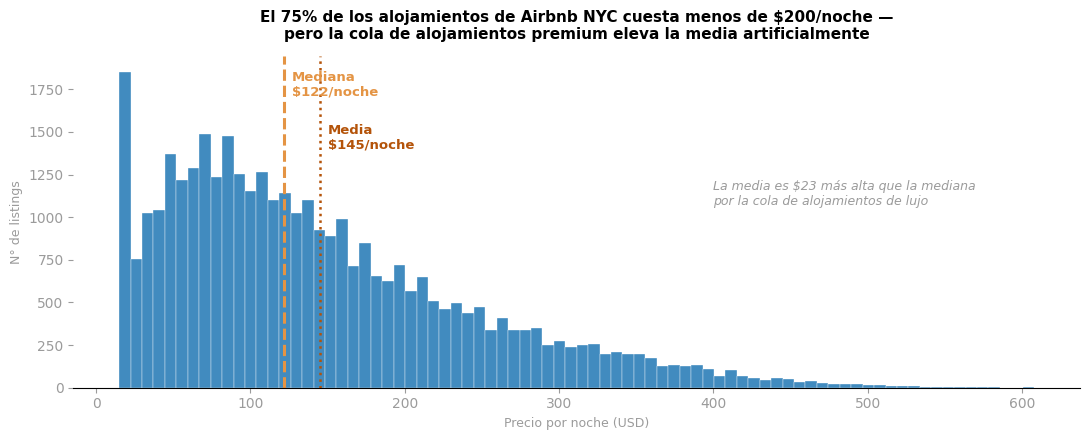

════════════════════════════════════════════════════════════
INSIGHT PARA EL REPORTE:
  Mediana: $122/noche  |  Media: $145/noche
  Diferencia: $23 (la media sobreestima el precio típico)
  El 75% de listings cuesta ≤ $200/noche
════════════════════════════════════════════════════════════


In [86]:
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.hist(df_clean['price'], bins=80, color=ACENTO, alpha=0.85,
        edgecolor='white', linewidth=0.3)

med = df_clean['price'].median()
mea = df_clean['price'].mean()

ax.axvline(med, color=TEAL, lw=2.2, linestyle='--')
ax.axvline(mea, color='#B45309', lw=1.8, linestyle=':')

# Anotaciones directas — sin leyenda
ymax = ax.get_ylim()[1]
ax.text(med+5, ymax*0.88, f'Mediana\n${med:.0f}/noche', color=TEAL,
        fontsize=9.5, fontweight='bold')
ax.text(mea+5, ymax*0.72, f'Media\n${mea:.0f}/noche', color='#B45309',
        fontsize=9.5, fontweight='bold')
ax.text(400, ymax*0.55,
        f'La media es ${mea-med:.0f} más alta que la mediana\npor la cola de alojamientos de lujo',
        color=GRIS, fontsize=9, style='italic')

ax.set_title(
    'El 75% de los alojamientos de Airbnb NYC cuesta menos de $200/noche —\n'
    'pero la cola de alojamientos premium eleva la media artificialmente',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Precio por noche (USD)', color=GRIS, fontsize=9)
ax.set_ylabel('N° de listings', color=GRIS, fontsize=9)
ax.tick_params(colors=GRIS)

plt.tight_layout()
plt.savefig('viz1_distribucion_precios.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight para el reporte
print('═'*60)
print('INSIGHT PARA EL REPORTE:')
print(f'  Mediana: ${med:.0f}/noche  |  Media: ${mea:.0f}/noche')
print(f'  Diferencia: ${mea-med:.0f} (la media sobreestima el precio típico)')
print(f'  El 75% de listings cuesta ≤ ${df_clean.price.quantile(0.75):.0f}/noche')
print('═'*60)


---
## Visualización 2 · Ranking de barrios por precio
**Pregunta de negocio:** ¿En qué barrio están los alojamientos más caros? ¿Cuánto más caros?

**Gráfico elegido:** Barras horizontales ordenadas de mayor a menor  
**Justificación:** La tarea es comparar magnitudes entre categorías. Posición en escala común permite una codificación más precisa. Ordenar de mayor a menor convierte el gráfico en un ranking legible. Horizontal porque los nombres de barrio son largos.


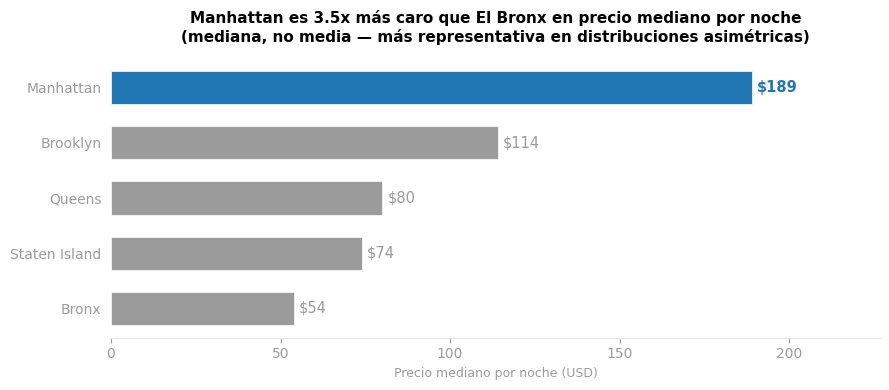

════════════════════════════════════════════════════════════
INSIGHT PARA EL REPORTE:
  Manhattan: $189  |  El Bronx: $54
  Ratio: Manhattan es 3.5x el precio del barrio más económico
════════════════════════════════════════════════════════════


In [87]:
precios = (df_clean.groupby('neighbourhood_group')['price']
                   .median()
                   .sort_values(ascending=True))  # ascending=True para barh ordenado de mayor a menor

fig, ax = plt.subplots(figsize=(9, 4))

colors = [ACENTO if v == precios.max() else GRIS for v in precios.values]
bars = ax.barh(precios.index, precios.values, color=colors, edgecolor='white', linewidth=0.5, height=0.6)

for bar, val in zip(bars, precios.values):
    ax.text(val + 1.5, bar.get_y() + bar.get_height()/2,
            f'${val:.0f}', va='center', fontsize=10.5,
            color=ACENTO if val == precios.max() else GRIS,
            fontweight='bold' if val == precios.max() else 'normal')

ax.set_xlim(0, precios.max() * 1.2)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#E8E8E8')
ax.tick_params(left=False, colors=GRIS)
ax.set_xlabel('Precio mediano por noche (USD)', color=GRIS, fontsize=9)

ratio = precios.max() / precios.min()
ax.set_title(
    f'Manhattan es {ratio:.1f}x más caro que El Bronx en precio mediano por noche\n'
    f'(mediana, no media — más representativa en distribuciones asimétricas)',
    fontsize=11, fontweight='bold'
)

plt.tight_layout()
plt.savefig('viz2_ranking_barrios.png', dpi=150, bbox_inches='tight')
plt.show()

print('═'*60)
print('INSIGHT PARA EL REPORTE:')
print(f'  Manhattan: ${precios.max():.0f}  |  El Bronx: ${precios.min():.0f}')
print(f'  Ratio: Manhattan es {ratio:.1f}x el precio del barrio más económico')
print('═'*60)

---
## Visualización 3 · Relación reviews vs. precio
**Pregunta de negocio:** ¿Los alojamientos más baratos acumulan más reviews? ¿Hay un patrón?

**Gráfico elegido:** Scatter plot con transparencia + línea de tendencia  
**Justificación:** La tarea es *relación entre dos variables cuantitativas*. Solo el scatter muestra co-variación punto a punto. Dos barras separadas (una de precio, una de reviews) NO pueden mostrar si están relacionadas. La transparencia (alpha) resuelve el overplotting con 48k puntos.

**Lo que muestra en una entrevista:** sabes que la correlación no se demuestra con barras, sabes manejar overplotting, y sabes leer e interpretar un scatter correctamente.

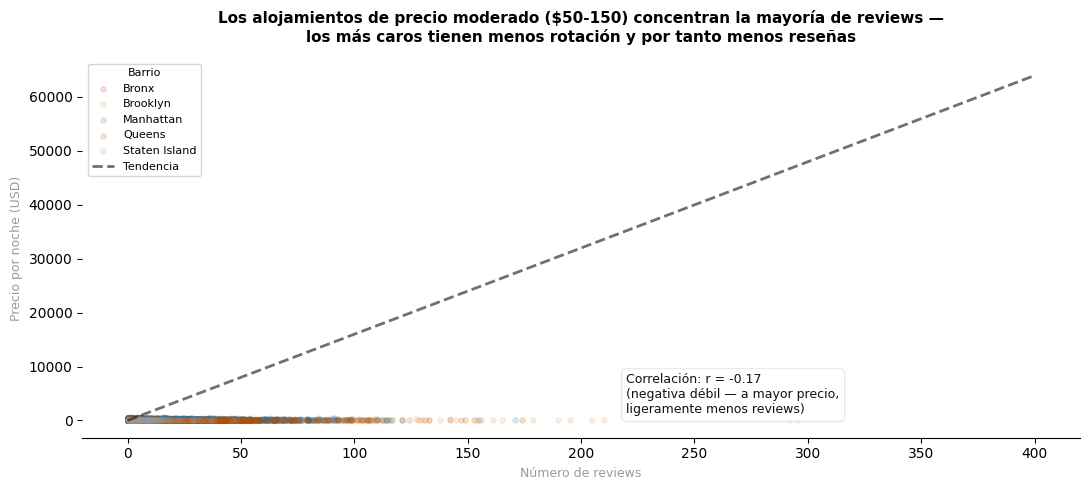

════════════════════════════════════════════════════════════
INSIGHT PARA EL REPORTE:
  Correlación precio vs. reviews: r = -0.170
  Relación negativa débil: los alojamientos más caros acumulan menos reviews.
  Interpretación posible: mayor rotación de huéspedes en el segmento económico.
════════════════════════════════════════════════════════════


In [88]:
muestra = (df_clean[df_clean['number_of_reviews'] < 400]
           .sample(n=min(6000, len(df_clean)), random_state=42))

barrio_colors = {
    'Manhattan':    ACENTO,
    'Brooklyn':     TEAL,
    'Queens':       '#B45309',
    'Bronx':        ALERTA,
    'Staten Island': GRIS,
}

fig, ax = plt.subplots(figsize=(11, 5))

for barrio, grp in muestra.groupby('neighbourhood_group'):
    ax.scatter(grp['number_of_reviews'], grp['price'],
               color=barrio_colors.get(barrio, GRIS),
               alpha=0.15, s=14, label=barrio)

# Línea de tendencia
c, m = np.polyfit(muestra['number_of_reviews'], muestra['price'], 1)
x_line = np.linspace(0, 400, 100)
ax.plot(x_line, c + m*x_line, color='#111111', lw=2, linestyle='--', alpha=0.6, label='Tendencia')

# Anotación del insight
corr = df_clean[['price','number_of_reviews']].corr().iloc[0,1]
ax.text(220, 1300, f'Correlación: r = {corr:.2f}\n(negativa débil — a mayor precio,\nligeramente menos reviews)',
        fontsize=9, color='#111111',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#E8E8E8', alpha=0.9))

ax.set_title(
    'Los alojamientos de precio moderado ($50-150) concentran la mayoría de reviews —\n'
    'los más caros tienen menos rotación y por tanto menos reseñas',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Número de reviews', color=GRIS, fontsize=9)
ax.set_ylabel('Precio por noche (USD)', color=GRIS, fontsize=9)
ax.legend(title='Barrio', fontsize=8, title_fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.savefig('viz3_reviews_vs_precio.png', dpi=150, bbox_inches='tight')
plt.show()

print('═'*60)
print('INSIGHT PARA EL REPORTE:')
print(f'  Correlación precio vs. reviews: r = {corr:.3f}')
print('  Relación negativa débil: los alojamientos más caros acumulan menos reviews.')
print('  Interpretación posible: mayor rotación de huéspedes en el segmento económico.')
print('═'*60)

---
## Visualización 4 · Composición por tipo de alojamiento
**Pregunta de negocio:** ¿La mezcla de tipos de alojamiento varía según el barrio?

**Gráfico elegido:** Stacked bar 100% (barras apiladas normalizadas)  
**Justificación:** La tarea es composición de partes dentro de grupos. Las barras absolutas serían engañosas porque Manhattan tiene muchos más listings que El Bronx. Al normalizar al 100% comparamos la estructura proporcional, respodiendo a la pregunta de negocio.


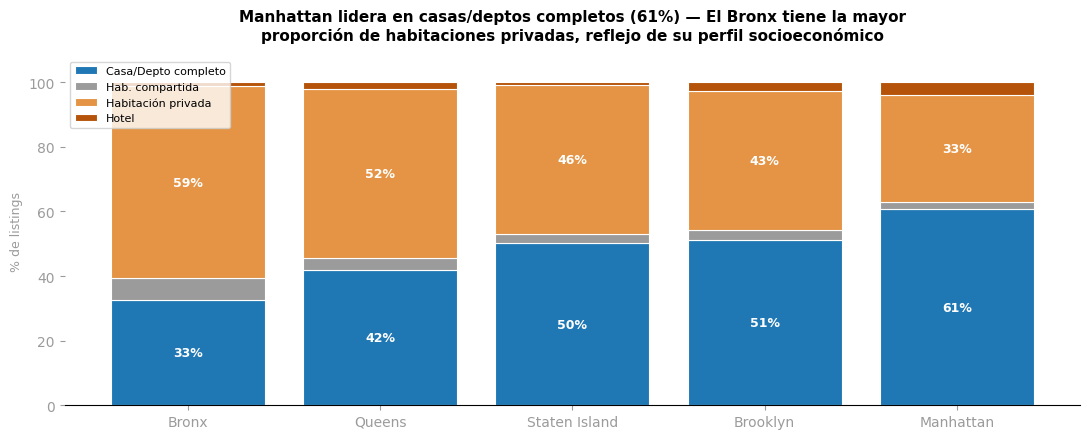

════════════════════════════════════════════════════════════
INSIGHT PARA EL REPORTE:
room_tipo            Casa/Depto completo  Habitación privada
neighbourhood_group                                         
Bronx                               32.7                59.4
Queens                              41.8                52.4
Staten Island                       50.1                46.1
Brooklyn                            51.2                42.9
Manhattan                           60.8                33.3
════════════════════════════════════════════════════════════


In [89]:
room_map = {
    'Entire home/apt': 'Casa/Depto completo',
    'Private room':    'Habitación privada',
    'Shared room':     'Hab. compartida',
    'Hotel room':      'Hotel',
}
df_clean['room_tipo'] = df_clean['room_type'].map(room_map).fillna('Otro')

pivot = df_clean.groupby(['neighbourhood_group','room_tipo']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Ordenar por % de casas completas
orden = pivot_pct['Casa/Depto completo'].sort_values(ascending=True).index
pivot_pct = pivot_pct.loc[orden]

colores_tipo = {
    'Casa/Depto completo': ACENTO,
    'Habitación privada':  TEAL,
    'Hotel':               '#B45309',
    'Hab. compartida':     GRIS,
    'Otro':                '#E8E8E8',
}

fig, ax = plt.subplots(figsize=(11, 4.5))
bottom = np.zeros(len(pivot_pct))

for col in pivot_pct.columns:
    vals = pivot_pct[col].values
    bars = ax.bar(pivot_pct.index, vals, bottom=bottom,
                  color=colores_tipo.get(col, GRIS),
                  label=col, edgecolor='white', linewidth=0.8)
    for bar, v, b in zip(bars, vals, bottom):
        if v > 9:
            ax.text(bar.get_x()+bar.get_width()/2, b+v/2,
                    f'{v:.0f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += vals

ax.set_ylim(0, 108)
ax.set_ylabel('% de listings', color=GRIS, fontsize=9)
ax.tick_params(colors=GRIS)
ax.legend(loc='upper left', fontsize=8, framealpha=0.8)

ax.set_title(
    'Manhattan lidera en casas/deptos completos (61%) — El Bronx tiene la mayor\n'
    'proporción de habitaciones privadas, reflejo de su perfil socioeconómico',
    fontsize=11, fontweight='bold'
)

plt.tight_layout()
plt.savefig('viz4_composicion_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

print('═'*60)
print('INSIGHT PARA EL REPORTE:')
print(pivot_pct[['Casa/Depto completo','Habitación privada']].round(1).to_string())
print('═'*60)

---
## Visualización 5 · Concentración de mercado
**Pregunta de negocio:** ¿El mercado de Airbnb NYC está concentrado en pocos hosts o es atomizado?

**Gráfico elegido:** Curva de concentración tipo Lorenz  
**Justificación:** La tarea es distribución acumulada de poder de mercado. Para decir cuánto del mercado controla cada host se aplicó la curva de Lorenz. La distancia respecto a la línea de 45° (igualdad perfecta) es el índice de Gini visual.


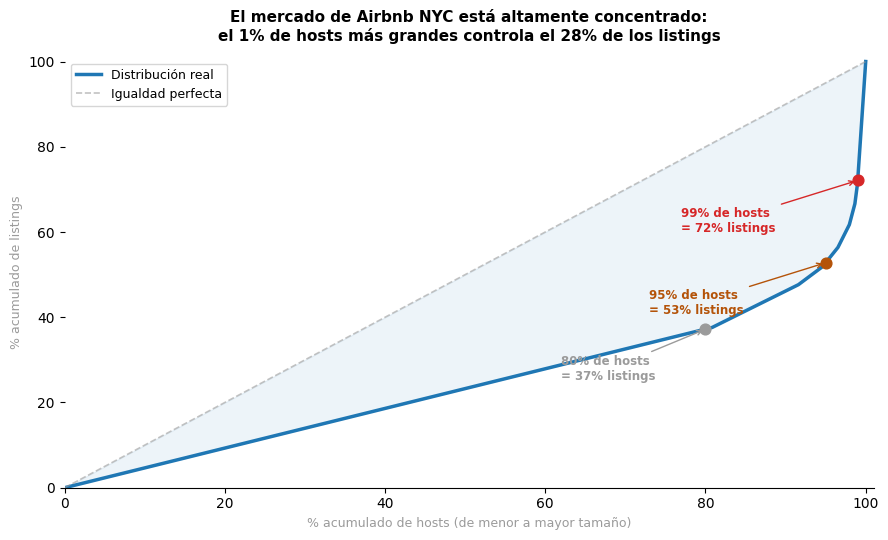

════════════════════════════════════════════════════════════
INSIGHT PARA EL REPORTE:
  El 1% de hosts más grandes controla el 28% del total de listings.
  El 80% de los hosts son "hosts individuales" (1-2 listings) y controlan
  solo el 37% del mercado.
  => Mercado altamente concentrado con pocos operadores profesionales grandes.
════════════════════════════════════════════════════════════


In [90]:
host_counts = df.groupby('host_id').size().sort_values()
total_hosts    = len(host_counts)
total_listings = host_counts.sum()

cum_hosts    = np.arange(1, total_hosts+1) / total_hosts * 100
cum_listings = host_counts.cumsum() / total_listings * 100

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(cum_hosts, cum_listings.values, color=ACENTO, lw=2.5, label='Distribución real')
ax.plot([0,100], [0,100], color=GRIS, lw=1.2, linestyle='--', alpha=0.6, label='Igualdad perfecta')
ax.fill_between(cum_hosts, cum_listings.values, cum_hosts, alpha=0.08, color=ACENTO)

# Anotaciones de insights clave
for pct_host, label_text, color in [(80, '80% de hosts', GRIS), (95, '95% de hosts', '#B45309'), (99, '99% de hosts', ALERTA)]:
    idx = int(total_hosts * pct_host/100) - 1
    pct_list = cum_listings.values[idx]
    ax.scatter(pct_host, pct_list, color=color, s=60, zorder=5)
    offset_x = -18 if pct_host < 90 else -22
    ax.annotate(
        f'{label_text}\n= {pct_list:.0f}% listings',
        xy=(pct_host, pct_list), xytext=(pct_host+offset_x, pct_list-12),
        fontsize=8.5, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color, lw=1)
    )

idx_1pct = int(total_hosts*0.99)
pct_top1 = 100 - cum_listings.values[idx_1pct]

ax.set_title(
    f'El mercado de Airbnb NYC está altamente concentrado:\n'
    f'el 1% de hosts más grandes controla el {pct_top1:.0f}% de los listings',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('% acumulado de hosts (de menor a mayor tamaño)', color=GRIS, fontsize=9)
ax.set_ylabel('% acumulado de listings', color=GRIS, fontsize=9)
ax.legend(fontsize=9, framealpha=0.8)
ax.set_xlim(0, 101); ax.set_ylim(0, 101)

plt.tight_layout()
plt.savefig('viz5_concentracion_mercado.png', dpi=150, bbox_inches='tight')
plt.show()

print('═'*60)
print('INSIGHT PARA EL REPORTE:')
print(f'  El 1% de hosts más grandes controla el {pct_top1:.0f}% del total de listings.')
print(f'  El 80% de los hosts son "hosts individuales" (1-2 listings) y controlan')
print(f'  solo el {cum_listings.values[int(total_hosts*0.8)]:.0f}% del mercado.')
print('  => Mercado altamente concentrado con pocos operadores profesionales grandes.')
print('═'*60)